# Part 1: Summary
1. Bias
* Definition: The error introduced by using a model that is too simple to capture the underlying patterns in the data, leading to underfitting.
* Characteristics: High bias causes the model to make strong assumptions, resulting in poor performance on both training and test datasets.

2. Variance
* Definition: The error introduced by a model being too complex and sensitive to small fluctuations or noise in the training data, leading to overfitting.
* Characteristics: High variance causes the model to perform exceptionally well on training data but poorly on unseen validation or test data.

3. Learning Curve
* Definition: A graphical plot showing the model's performance (error or loss) on both training and validation sets over time (epochs or dataset size).

4. Train Loss
* Definition: The error measured on the training dataset used to update model parameters.
* Characteristics: Train loss typically decreases continuously as the model learns the training data, even if it starts memorizing noise (overfitting).

5. Validation Loss
* Definition: The error measured on an independent validation dataset that the model has never seen during training.
* Characteristics: It decreases initially, but if training continues too long, validation loss reaches a minimum and starts increasing, signaling the onset of overfitting.

# Visualizing Overfitting, Underfitting, and Model Complexity
In this notebook, we will demonstrate how model complexity affects training and validation performance using polynomial regression.

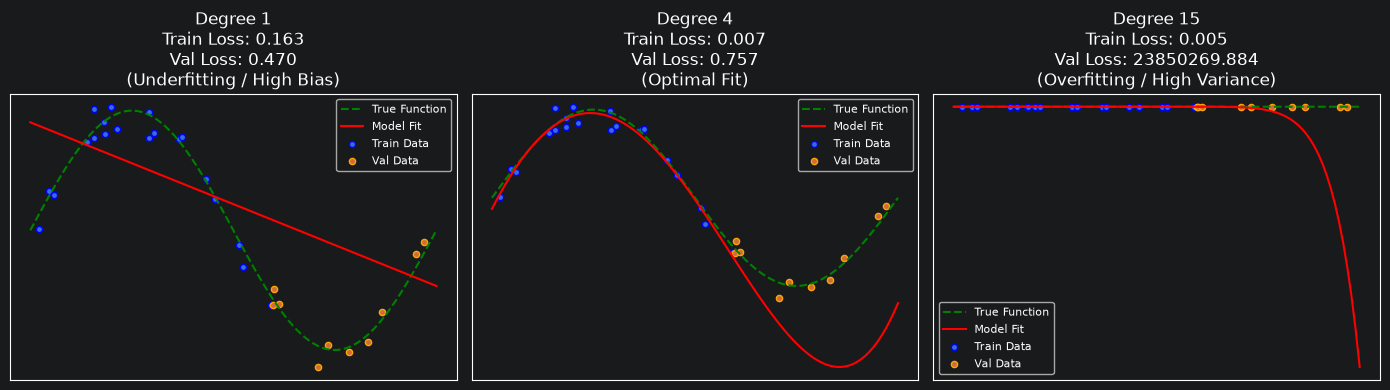

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Generate synthetic dataset based on a sine wave with noise
np.random.seed(42)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = np.sin(2 * np.pi * X) + np.random.randn(n_samples) * 0.1

# Split into train and validation sets
X_train, X_val = X[:20], X[20:]
y_train, y_val = y[:20], y[20:]

# 2. Test different polynomial degrees (Complexity)
degrees = [1, 4, 15]  # Underfitting, Good, Overfitting
plt.figure(figsize=(14, 4))

for i, degree in enumerate(degrees):
    ax = plt.subplot(1, len(degrees), i + 1)

    # Create polynomial regression pipeline
    polynomial_features = PolynomialFeatures(degree=degree, include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("poly_features", polynomial_features), ("regressor", linear_regression)])

    # Train the model
    pipeline.fit(X_train[:, np.newaxis], y_train)

    # Evaluate errors
    train_loss = mean_squared_error(y_train, pipeline.predict(X_train[:, np.newaxis]))
    val_loss = mean_squared_error(y_val, pipeline.predict(X_val[:, np.newaxis]))

    # Plotting
    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, np.sin(2 * np.pi * X_test), label="True Function", color="green", linestyle="--")
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model Fit", color="red")
    plt.scatter(X_train, y_train, edgecolor="b", s=20, label="Train Data")
    plt.scatter(X_val, y_val, edgecolor="orange", s=20, label="Val Data")

    title = f"Degree {degree}\nTrain Loss: {train_loss:.3f}\nVal Loss: {val_loss:.3f}"
    if degree == 1:
        title += "\n(Underfitting / High Bias)"
    elif degree == 4:
        title += "\n(Optimal Fit)"
    else:
        title += "\n(Overfitting / High Variance)"

    plt.setp(ax, xticks=[], yticks=[])
    plt.title(title)
    plt.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()

### Train Loss vs. Validation Loss Curve
As training progresses (or as model complexity increases), the training loss keeps dropping, while the validation loss reaches an optimal point and then starts rising due to overfitting.

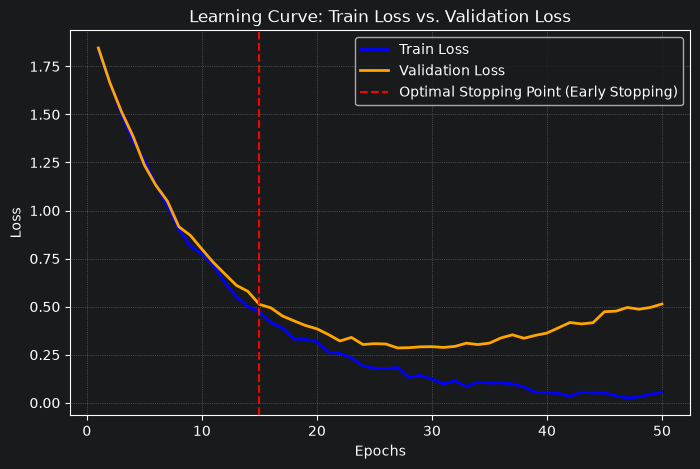

In [2]:
# Simulating a typical deep learning training curve (epochs vs loss)
epochs = 50
train_losses = []
val_losses = []

np.random.seed(0)
for epoch in range(1, epochs + 1):
    # Train loss steadily decreases
    t_loss = 2.0 * np.exp(-epoch / 10.0) + 0.05 * np.random.rand()
    # Validation loss decreases then starts increasing (overfitting)
    v_loss = 2.0 * np.exp(-epoch / 10.0) + 0.02 * (epoch / 10.0)**2 + 0.05 * np.random.rand()

    train_losses.append(t_loss)
    val_losses.append(v_loss)

# Plotting the Learning Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, label="Train Loss", color="blue", linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss", color="orange", linewidth=2)
plt.axvline(x=15, color="red", linestyle="--", label="Optimal Stopping Point (Early Stopping)")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Learning Curve: Train Loss vs. Validation Loss")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()